In [10]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [11]:
import os
os.chdir("/scratch/go76fil/Programs/Python/Paper_Topic_Modelling")
os.getcwd()

'/scratch/go76fil/Programs/Python/Paper_Topic_Modelling'

In [12]:
import pickle
with open('./output/store/pdf_files.pkl', 'rb') as f:
    pdf_files, year = pickle.load(f)
with open('./output/store/preprocessed_pdf_files.pkl', 'rb') as f:
    preprocessed_pdf_files, _ = pickle.load(f)
with open('./output/store/light_preprocessed_pdf_files.pkl', 'rb') as f:
    light_preprocessed_pdf_files, _ = pickle.load(f)

In [13]:
print(len(pdf_files))
print(len(preprocessed_pdf_files))
print(len(light_preprocessed_pdf_files))

555
555
555


In [24]:
from src.optimisation import MTObjective, CLObjective, OCDObjective, CNTObjective
from src.optimisation import basic_space  
from numpy.random import default_rng
seed = 42
objective = CNTObjective(
    docs=light_preprocessed_pdf_files,
    analyzer="word",
    seed=seed,
    gpu=True,
    top_n=50
)
space = basic_space()

In [25]:
from hyperopt import fmin, tpe, Trials, space_eval

trials = Trials()
best = fmin(
    fn=objective,        
    space=space,           
    algo=tpe.suggest,      
    max_evals=100,          
    trials=trials,
    rstate=default_rng(seed)
)
best_hyperparams = space_eval(space, best)

print("Best hyperparameters:")
print(best_hyperparams)

Error with params {'embedding_model': 'allenai/scibert_scivocab_uncased', 'hdbscan_model': {'min_cluster_size': 29, 'min_samples': 17}, 'umap_model': {'metric': 'manhattan', 'min_dist': 0.059936189081400526, 'n_components': 10, 'n_neighbors': 16}}: max_df corresponds to < documents than min_df
Error with params {'embedding_model': 'sentence-transformers/all-MiniLM-L6-v2', 'hdbscan_model': {'min_cluster_size': 5, 'min_samples': 12}, 'umap_model': {'metric': 'manhattan', 'min_dist': 0.7044600162750467, 'n_components': 4, 'n_neighbors': 21}}: unable to interpret topic as either a list of tokens or a list of ids
Error with params {'embedding_model': 'sentence-transformers/all-MiniLM-L6-v2', 'hdbscan_model': {'min_cluster_size': 45, 'min_samples': 9}, 'umap_model': {'metric': 'manhattan', 'min_dist': 0.7231479244442287, 'n_components': 3, 'n_neighbors': 38}}: max_df corresponds to < documents than min_df
100%|███████████████████████████████████████| 10/10 [07:38<00:00, 45.85s/trial, best lo

In [28]:
with open('./output/store/CNT_100.pkl', 'wb') as f:
    pickle.dump((trials,best_hyperparams), f)

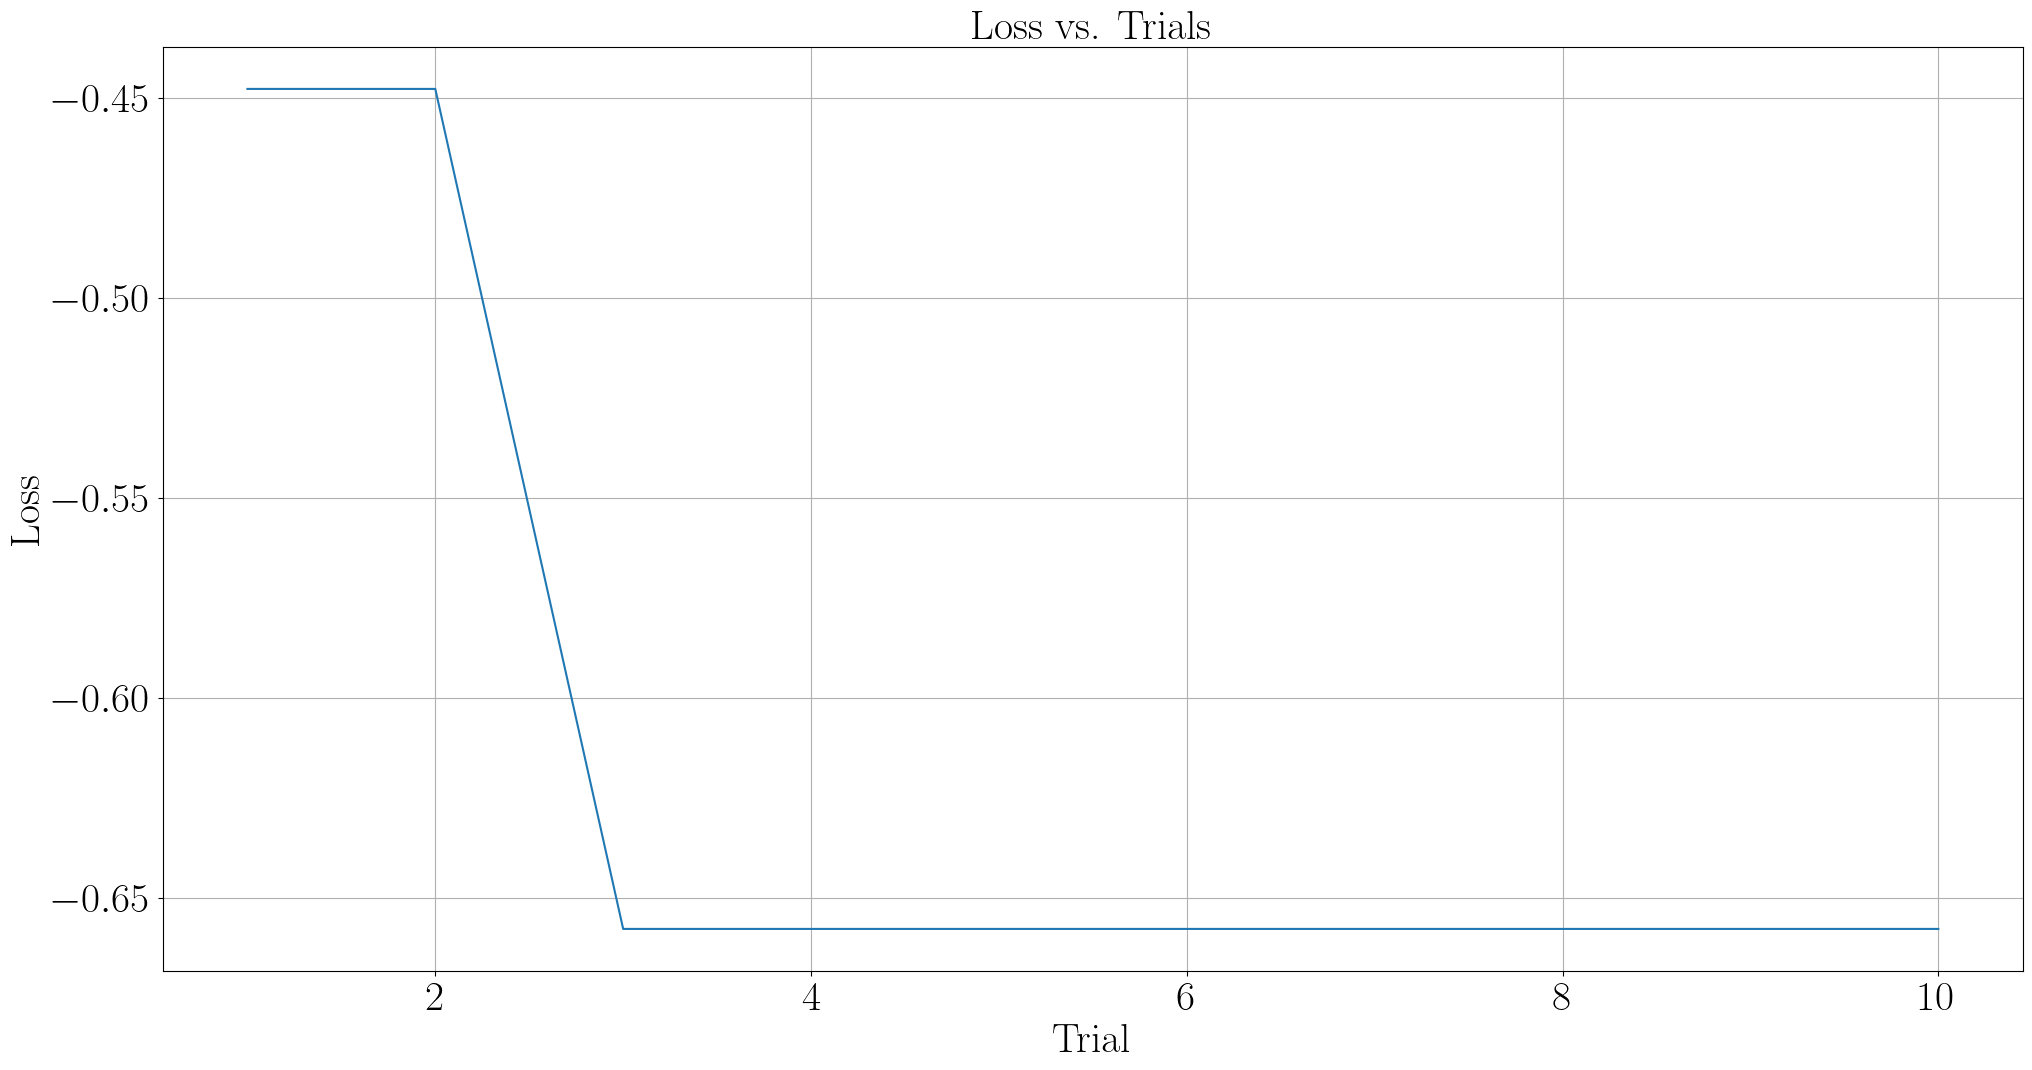

In [27]:
from src.optimisation import plot_best_loss
plot_best_loss(trials)